# Verificación de Momentos de Legendre — tape NJOY iwt1 con peso SpekPy tabulado

**Caso:** tapes `gendf_*_iwt1` · `lord = 3` · peso espectral SpekPy tabulado leído de archivo

Comparación **directa, sin maquillaje**, de los momentos de Legendre del kernel
multigrupo Compton del solver vs NJOY MF=26 / MT=504.

**Dos cuadraturas reales del solver, idéntica física, sólo cambia N:**

| Rama | Cuadratura | Nº puntos | Significado |
|:----:|:----------:|:---------:|:------------|
| **A** | Gauss-Legendre | **N = 26**  (= S26 efectivo en μ) | primeros vecinos |
| **B** | Gauss-Legendre | **N = 128** (= S128 efectivo en μ) | segundos vecinos |

**FCS restringida a primeros vecinos:** la FCS sólo va a primeros vecinos (S26).
No se construye FCS a segundos vecinos. La rama S128 se usa exclusivamente para verificar
el kernel angular contra NJOY, no para extender la FCS.

**Convención de momentos (la que usa NJOY GROUPR para MF=6/MF=26):**

$$\boxed{\;\sigma_l(g'\to g) \;=\; 2\pi \int_{-1}^{+1} P_l(\mu)\,\sigma_s^{g'\to g}(\mu)\,d\mu\;}$$

(NJOY GAMINR manual §10: el tape almacena directamente $f_l = 2\pi\int P_l\,\sigma\,d\mu$)

**Peso energético (iwt=1):** El manual NJOY-2016 define `iwt=1` como **peso tabulado en archivo**.
El archivo usado aquí es exactamente el mismo que se entregó a NJOY/GAMINR al generar los tapes
`*_iwt1`. NO se reinventa, NO se sustituye por w(E)=1, NO se sustituye por w(E)=1/E.

**Tapes (fijos):**
- `/home/rober/njoy_work/tapes/gendf_HO_0_100_10keV_lord3_iwt1`
- `/home/rober/njoy_work/tapes/gendf_N_0_100_10keV_lord3_iwt1`

**Archivo de peso (fijo):**
- `/home/rober/njoy_work/tapes/spekpy_weight_iwt1_96.txt`

---
## Celda 0 — Imports

In [1]:
# CELDA 0 — Imports
import math, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path

print('OK  Imports')

OK  Imports


---
## Celda 1 — Configuración global, constantes, grupos y peso SpekPy iwt=1

In [2]:
# CELDA 1 — Configuración global  (tape NJOY iwt1 con peso SpekPy tabulado)
# NJOY/GAMINR iwt=1: peso espectral tabulado en archivo.
# El peso NO se inventa: se LEE del mismo archivo que se usó al generar los tapes NJOY/GAMINR.

IWT = 1
WEIGHT_LABEL = "peso SpekPy tabulado (iwt=1) — leído de archivo"

# ── Rutas fijas (tapes y peso) ───────────────────────────────────────────
WEIGHT_SPEKPY = Path("/home/rober/njoy_work/tapes/spekpy_weight_iwt1_96.txt")
TAPE_HO       = Path("/home/rober/njoy_work/tapes/gendf_HO_0_100_10keV_lord3_iwt1")
TAPE_N        = Path("/home/rober/njoy_work/tapes/gendf_N_0_100_10keV_lord3_iwt1")

print("── Comprobación de archivos ─────────────────────────────────────")
for label, p in [("WEIGHT_SPEKPY", WEIGHT_SPEKPY), ("TAPE_HO", TAPE_HO), ("TAPE_N", TAPE_N)]:
    print(f"  {label:>13}: {p}")
    print(f"  {'existe':>13}: {p.exists()}")
print()

if not WEIGHT_SPEKPY.exists():
    raise FileNotFoundError(
        f"No se encuentra el archivo de peso SpekPy:\n  {WEIGHT_SPEKPY}\n"
        f"Sin este archivo no se puede colapsar consistentemente con NJOY iwt=1."
    )

# ── Lectura del peso SpekPy ─────────────────────────────────────────────
# Robusto a: cabeceras "#" o "%", delimitador libre, >2 columnas (se toman 0 y 1).
_wdata = np.loadtxt(WEIGHT_SPEKPY, comments=["#", "%"])
if _wdata.ndim == 1:
    raise ValueError(f"{WEIGHT_SPEKPY} debe tener al menos 2 columnas (E, w).")

E_WEIGHT_RAW = _wdata[:, 0].astype(float)
W_WEIGHT_RAW = _wdata[:, 1].astype(float)

# Detectar unidades: si el max excede 1000 asumimos eV, convertimos a keV.
# (El espectro iwt=1 está en [0, 100] keV, equivalente [0, 1e5] eV.)
_e_max = float(np.max(E_WEIGHT_RAW))
if _e_max > 1000.0:
    E_WEIGHT  = E_WEIGHT_RAW / 1000.0
    _unit_src = "eV (convertido a keV)"
else:
    E_WEIGHT  = E_WEIGHT_RAW.copy()
    _unit_src = "keV"

# Pesos no negativos (seguridad numérica; no se renormaliza: el promedio es num/den).
W_WEIGHT = np.clip(W_WEIGHT_RAW, 0.0, None)

# Orden creciente (np.interp lo exige).
_isort   = np.argsort(E_WEIGHT)
E_WEIGHT = E_WEIGHT[_isort]
W_WEIGHT = W_WEIGHT[_isort]

E_WEIGHT_MIN = float(E_WEIGHT.min())
E_WEIGHT_MAX = float(E_WEIGHT.max())


def _weight(E_keV: float) -> float:
    """Peso energético para colapso multigrupo. iwt=1: SpekPy(E) tabulado.

    - Lectura directa del archivo de peso usado al generar NJOY/GAMINR iwt=1.
    - Interpolación lineal sobre la rejilla del archivo.
    - Fuera del rango tabulado devuelve 0 (no extrapolar).
    - NO sustituye por w(E)=1 ni por w(E)=1/E.
    """
    E_keV = float(E_keV)
    if E_keV < E_WEIGHT_MIN or E_keV > E_WEIGHT_MAX:
        return 0.0
    w = float(np.interp(E_keV, E_WEIGHT, W_WEIGHT))
    return w if w > 0.0 else 0.0


# ── Constantes físicas (CGS) ─────────────────────────────────────────────
N_A         = 6.02214076e23
r_e_cm      = 2.8179403262e-13
mec2_keV    = 511.0
DELTA_E_KEV = 1.0

# ── Grupos de energía: IDÉNTICOS a iwt=3 ────────────────────────────────
ENERGY_GROUPS = [
    (100, 90), (90, 80), (80, 70), (70, 60), (60, 50),
    (50, 40),  (40, 30), (30, 20), (20, 10), (10,  0),
]
N_GROUPS  = len(ENERGY_GROUPS)
E_MIN_KEV = 20.0
E_MAX_KEV = 80.0

def active_groups():
    return [g for g, (hi, lo) in enumerate(ENERGY_GROUPS)
            if hi > E_MIN_KEV and lo < E_MAX_KEV]

def energy_bins_in_group(g):
    hi, lo = ENERGY_GROUPS[g]
    return np.arange(float(lo) + 0.5, float(hi) + 0.5, DELTA_E_KEV)

def energy_bins_in_range(g):
    return [E for E in energy_bins_in_group(g) if E_MIN_KEV <= E <= E_MAX_KEV]

# Etiquetas (ascendente, igual que NJOY) — IGUAL que en iwt=3
GROUP_LABELS   = ["20-30", "30-40", "40-50", "50-60", "60-70", "70-80"]
GROUP_BTE_IDX  = [7, 6, 5, 4, 3, 2]   # BTE (descendente)
GROUP_NJOY_IDX = [2, 3, 4, 5, 6, 7]   # NJOY (ascendente, 0-based)
N_G = len(GROUP_LABELS)

# Materiales — IGUAL que en iwt=3
RHO_H2O = 1.0
RHO_AIR = 1.2e-3
COMP_H2O = pd.DataFrame({"H": [11.1898], "O": [88.8102], "N": [0.0]})
COMP_AIR = pd.DataFrame({"H": [0.0],     "O": [24.3672], "N": [75.6328]})

# Fracciones másicas (Bragg)
MIX_H2O = {"H": 0.111898, "O": 0.888102}
MIX_AIR = {"N": 0.756328, "O": 0.243672}

print(f"OK  IWT={IWT} | {WEIGHT_LABEL}")
print(f"    Puntos peso     : {len(E_WEIGHT)}")
print(f"    Unidad original : {_unit_src}")
print(f"    Rango energético: [{E_WEIGHT_MIN:.4g}, {E_WEIGHT_MAX:.4g}] keV")
print(f"    w(E) min/max    : [{float(W_WEIGHT.min()):.4g}, {float(W_WEIGHT.max()):.4g}]")
print(f"    Grupos activos  : {active_groups()} | E=[{E_MIN_KEV},{E_MAX_KEV}] keV")

── Comprobación de archivos ─────────────────────────────────────
  WEIGHT_SPEKPY: /home/rober/njoy_work/tapes/spekpy_weight_iwt1_96.txt
         existe: True
        TAPE_HO: /home/rober/njoy_work/tapes/gendf_HO_0_100_10keV_lord3_iwt1
         existe: True
         TAPE_N: /home/rober/njoy_work/tapes/gendf_N_0_100_10keV_lord3_iwt1
         existe: True

OK  IWT=1 | peso SpekPy tabulado (iwt=1) — leído de archivo
    Puntos peso     : 96
    Unidad original : eV (convertido a keV)
    Rango energético: [0, 99.5] keV
    w(E) min/max    : [0, 9.98e+06]
    Grupos activos  : [2, 3, 4, 5, 6, 7] | E=[20.0,80.0] keV


---
## Celda 2 — `PointCrossSections` — KN × S(x,Z), ENDF/B-VII.1 MT=504

In [3]:
# CELDA 2 — PointCrossSections
# Compton incoherente KN x S(x,Z). Tablas ENDF/B-VII.1 MT=504.

_Z_ELEM = {'H': 1, 'O': 8, 'N': 7}
_A_ELEM = {'H': 1.00794, 'O': 15.9994, 'N': 14.0067}

_S_X_H = np.array([
    0.000000e+00, 1.000000e-07, 1.000000e-06, 1.000000e-05, 1.000000e-04, 1.000000e-03,
    5.000000e-03, 1.000000e-02, 1.500000e-02, 2.000000e-02, 2.500000e-02, 3.000000e-02,
    3.750000e-02, 4.000000e-02, 4.750000e-02, 5.000000e-02, 5.875000e-02, 6.625000e-02,
    7.000000e-02, 7.875000e-02, 8.000000e-02, 8.625000e-02, 9.000000e-02, 9.750000e-02,
    1.000000e-01, 1.062500e-01, 1.156300e-01, 1.250000e-01, 1.359400e-01, 1.453100e-01,
    1.500000e-01, 1.609400e-01, 1.703100e-01, 1.750000e-01, 1.875000e-01, 2.000000e-01,
    2.125000e-01, 2.218800e-01, 2.289100e-01, 2.359400e-01, 2.429700e-01, 2.500000e-01,
    2.625000e-01, 2.718800e-01, 2.789100e-01, 2.906300e-01, 2.929700e-01, 3.000000e-01,
    3.179700e-01, 3.250000e-01, 3.330100e-01, 3.497600e-01, 3.625000e-01, 3.677000e-01,
    3.892300e-01, 4.000000e-01, 4.250000e-01, 4.437500e-01, 4.500000e-01, 4.718800e-01,
    5.000000e-01, 5.250000e-01, 5.625000e-01, 6.000000e-01, 6.500000e-01, 7.000000e-01,
    7.500000e-01, 8.000000e-01, 8.750000e-01, 9.000000e-01, 1.000000e+00, 1.125000e+00,
    1.250000e+00, 1.437500e+00, 1.500000e+00, 1.750000e+00, 2.000000e+00, 2.500000e+00,
    3.000000e+00, 3.500000e+00, 4.000000e+00, 5.000000e+00, 6.000000e+00, 7.000000e+00,
    8.000000e+00, 1.000000e+01, 1.500000e+01, 2.000000e+01, 5.000000e+01, 8.000000e+01,
    1.000000e+02, 1.000000e+03, 1.000000e+06, 1.000000e+09,
], dtype=float)
_S_VAL_H = np.array([
    0.000000e+00, 4.409700e-13, 4.409700e-11, 4.409700e-09, 4.409700e-07, 4.409700e-05,
    1.102425e-03, 4.409700e-03, 9.887600e-03, 1.749400e-02, 2.716600e-02, 3.882600e-02,
    5.983670e-02, 6.772900e-02, 9.383850e-02, 1.033100e-01, 1.391020e-01, 1.726290e-01,
    1.902300e-01, 2.329580e-01, 2.392320e-01, 2.710060e-01, 2.903800e-01, 3.294640e-01,
    3.425600e-01, 3.752390e-01, 4.238310e-01, 4.713000e-01, 5.245410e-01, 5.678810e-01,
    5.887300e-01, 6.347230e-01, 6.712280e-01, 6.885000e-01, 7.310720e-01, 7.688400e-01,
    8.019520e-01, 8.240260e-01, 8.392010e-01, 8.530840e-01, 8.658780e-01, 8.776800e-01,
    8.961610e-01, 9.082310e-01, 9.163850e-01, 9.283980e-01, 9.305910e-01, 9.368600e-01,
    9.502770e-01, 9.546510e-01, 9.592280e-01, 9.673380e-01, 9.723280e-01, 9.741820e-01,
    9.804080e-01, 9.829800e-01, 9.875650e-01, 9.901100e-01, 9.908580e-01, 9.930070e-01,
    9.950200e-01, 9.962740e-01, 9.975580e-01, 9.983700e-01, 9.989660e-01, 9.994100e-01,
    9.995910e-01, 9.997600e-01, 9.998670e-01, 9.999000e-01, 9.999500e-01, 9.999710e-01,
    9.999900e-01, 9.999980e-01, 1.000000e+00, 1.000000e+00, 1.000000e+00, 1.000000e+00,
    1.000000e+00, 1.000000e+00, 1.000000e+00, 1.000000e+00, 1.000000e+00, 1.000000e+00,
    1.000000e+00, 1.000000e+00, 1.000000e+00, 1.000000e+00, 1.000000e+00, 1.000000e+00,
    1.000000e+00, 1.000000e+00, 1.000000e+00, 1.000000e+00,
], dtype=float)

_S_X_O = np.array([
    0.000000e+00, 1.000000e-07, 1.000000e-06, 1.000000e-05, 1.000000e-04, 1.000000e-03,
    5.000000e-03, 6.250000e-03, 7.187500e-03, 7.890600e-03, 8.945300e-03, 1.000000e-02,
    1.500000e-02, 1.750000e-02, 2.000000e-02, 2.500000e-02, 3.000000e-02, 4.000000e-02,
    5.000000e-02, 6.000000e-02, 7.000000e-02, 8.000000e-02, 8.500000e-02, 9.000000e-02,
    1.000000e-01, 1.125000e-01, 1.250000e-01, 1.375000e-01, 1.500000e-01, 1.625000e-01,
    1.750000e-01, 1.875000e-01, 1.937500e-01, 2.000000e-01, 2.125000e-01, 2.312500e-01,
    2.500000e-01, 2.718800e-01, 2.906300e-01, 3.000000e-01, 3.250000e-01, 3.437500e-01,
    3.625000e-01, 3.718800e-01, 4.000000e-01, 4.250000e-01, 4.625000e-01, 4.750000e-01,
    5.000000e-01, 5.500000e-01, 5.875000e-01, 6.000000e-01, 6.500000e-01, 7.000000e-01,
    7.500000e-01, 8.000000e-01, 9.000000e-01, 1.000000e+00, 1.109400e+00, 1.203100e+00,
    1.250000e+00, 1.312500e+00, 1.406300e+00, 1.500000e+00, 1.589800e+00, 1.665000e+00,
    1.748800e+00, 1.750000e+00, 1.838500e+00, 1.919300e+00, 2.000000e+00, 2.062500e+00,
    2.335900e+00, 2.375000e+00, 2.445300e+00, 2.500000e+00, 2.750000e+00, 2.835900e+00,
    2.894500e+00, 2.947300e+00, 3.000000e+00, 3.062500e+00, 3.117200e+00, 3.212900e+00,
    3.392300e+00, 3.464100e+00, 3.500000e+00, 3.562500e+00, 3.671900e+00, 3.877000e+00,
    3.959000e+00, 4.000000e+00, 4.091800e+00, 4.176000e+00, 4.279000e+00, 4.327100e+00,
    5.000000e+00, 5.125000e+00, 5.343800e+00, 5.753900e+00, 5.918000e+00, 6.000000e+00,
    6.562500e+00, 7.000000e+00, 8.000000e+00, 1.000000e+01, 1.500000e+01, 1.000000e+09,
], dtype=float)
_S_VAL_O = np.array([
    0.000000e+00, 1.100000e-12, 1.100000e-10, 1.100000e-08, 1.100000e-06, 1.100000e-04,
    2.750000e-03, 4.296875e-03, 5.682617e-03, 6.848773e-03, 8.802023e-03, 1.100000e-02,
    2.530000e-02, 3.441520e-02, 4.480000e-02, 6.980000e-02, 1.001000e-01, 1.761000e-01,
    2.710000e-01, 3.841910e-01, 5.137000e-01, 6.568110e-01, 7.328590e-01, 8.118000e-01,
    9.770000e-01, 1.194080e+00, 1.419900e+00, 1.651210e+00, 1.885000e+00, 2.118480e+00,
    2.349700e+00, 2.576840e+00, 2.688710e+00, 2.799000e+00, 3.014080e+00, 3.322920e+00,
    3.613500e+00, 3.927910e+00, 4.176130e+00, 4.293000e+00, 4.580310e+00, 4.774320e+00,
    4.951080e+00, 5.033340e+00, 5.257000e+00, 5.429000e+00, 5.647990e+00, 5.711810e+00,
    5.828000e+00, 6.020960e+00, 6.139280e+00, 6.175000e+00, 6.301780e+00, 6.411000e+00,
    6.507880e+00, 6.596000e+00, 6.755000e+00, 6.901000e+00, 7.047320e+00, 7.161580e+00,
    7.215900e+00, 7.283300e+00, 7.377340e+00, 7.462000e+00, 7.533340e+00, 7.586660e+00,
    7.639770e+00, 7.640450e+00, 7.689840e+00, 7.729440e+00, 7.764200e+00, 7.787300e+00,
    7.867040e+00, 7.875420e+00, 7.890010e+00, 7.899900e+00, 7.934000e+00, 7.943210e+00,
    7.948220e+00, 7.952650e+00, 7.957000e+00, 7.960700e+00, 7.963880e+00, 7.969320e+00,
    7.976770e+00, 7.979400e+00, 7.980700e+00, 7.982170e+00, 7.984680e+00, 7.989170e+00,
    7.990400e+00, 7.991000e+00, 7.991770e+00, 7.992470e+00, 7.993300e+00, 7.993680e+00,
    7.997700e+00, 7.997920e+00, 7.998280e+00, 7.998930e+00, 7.999180e+00, 7.999300e+00,
    7.999590e+00, 7.999800e+00, 8.000000e+00, 8.000000e+00, 8.000000e+00, 8.000000e+00,
], dtype=float)

_S_X_N = np.array([
    0.000000e+00, 1.000000e-07, 1.000000e-06, 1.000000e-05, 1.000000e-04, 1.000000e-03,
    5.000000e-03, 6.718700e-03, 7.890600e-03, 9.296900e-03, 1.000000e-02, 1.125000e-02,
    1.500000e-02, 2.000000e-02, 2.500000e-02, 3.000000e-02, 4.000000e-02, 5.000000e-02,
    5.875000e-02, 6.000000e-02, 7.000000e-02, 8.000000e-02, 9.000000e-02, 1.000000e-01,
    1.109400e-01, 1.125000e-01, 1.203100e-01, 1.250000e-01, 1.375000e-01, 1.500000e-01,
    1.625000e-01, 1.750000e-01, 1.875000e-01, 1.937500e-01, 2.000000e-01, 2.125000e-01,
    2.312500e-01, 2.500000e-01, 2.718800e-01, 2.750000e-01, 2.906300e-01, 3.000000e-01,
    3.250000e-01, 3.437500e-01, 3.718800e-01, 4.000000e-01, 4.437500e-01, 4.812500e-01,
    5.000000e-01, 5.250000e-01, 5.625000e-01, 5.750000e-01, 6.000000e-01, 6.500000e-01,
    7.000000e-01, 8.000000e-01, 8.750000e-01, 9.000000e-01, 9.750000e-01, 1.000000e+00,
    1.085900e+00, 1.144500e+00, 1.214800e+00, 1.250000e+00, 1.312500e+00, 1.406300e+00,
    1.500000e+00, 1.617200e+00, 1.712900e+00, 1.750000e+00, 1.784700e+00, 1.838500e+00,
    1.919300e+00, 2.000000e+00, 2.062500e+00, 2.308600e+00, 2.375000e+00, 2.377000e+00,
    2.459000e+00, 2.500000e+00, 2.750000e+00, 2.835900e+00, 2.894500e+00, 2.947300e+00,
    3.000000e+00, 3.062500e+00, 3.117200e+00, 3.212900e+00, 3.392300e+00, 3.464100e+00,
    3.500000e+00, 3.562500e+00, 3.671900e+00, 4.000000e+00, 4.125000e+00, 4.234400e+00,
    4.425800e+00, 5.000000e+00, 5.250000e+00, 5.718800e+00, 6.000000e+00, 6.625000e+00,
    6.875000e+00, 7.000000e+00, 7.250000e+00, 7.718800e+00, 7.906300e+00, 8.000000e+00,
    8.125000e+00, 8.359400e+00, 8.654200e+00, 8.900900e+00, 9.529000e+00, 1.000000e+01,
    1.045900e+01, 1.088000e+01, 1.139500e+01, 1.205600e+01, 1.247700e+01, 1.373800e+01,
    1.500000e+01, 1.718800e+01, 1.906300e+01, 2.000000e+01, 1.000000e+09,
], dtype=float)
_S_VAL_N = np.array([
    0.000000e+00, 1.300000e-12, 1.300000e-10, 1.300000e-08, 1.300000e-06, 1.300000e-04,
    3.250000e-03, 5.868321e-03, 8.094004e-03, 1.123621e-02, 1.300000e-02, 1.649010e-02,
    2.920000e-02, 5.170000e-02, 8.040000e-02, 1.151000e-01, 2.017000e-01, 3.100000e-01,
    4.200330e-01, 4.368180e-01, 5.797000e-01, 7.364600e-01, 9.042000e-01, 1.080000e+00,
    1.278750e+00, 1.307440e+00, 1.452170e+00, 1.539700e+00, 1.772470e+00, 2.003000e+00,
    2.228330e+00, 2.446800e+00, 2.657050e+00, 2.758520e+00, 2.858000e+00, 3.048640e+00,
    3.315380e+00, 3.558600e+00, 3.812940e+00, 3.846890e+00, 4.007360e+00, 4.097000e+00,
    4.311800e+00, 4.453020e+00, 4.636790e+00, 4.792000e+00, 4.987420e+00, 5.122470e+00,
    5.182000e+00, 5.254070e+00, 5.350560e+00, 5.380580e+00, 5.437000e+00, 5.540240e+00,
    5.635000e+00, 5.809000e+00, 5.929580e+00, 5.968000e+00, 6.077840e+00, 6.113000e+00,
    6.226560e+00, 6.298480e+00, 6.378060e+00, 6.415700e+00, 6.477240e+00, 6.558950e+00,
    6.630000e+00, 6.703240e+00, 6.753430e+00, 6.770310e+00, 6.785630e+00, 6.806880e+00,
    6.835130e+00, 6.859900e+00, 6.875510e+00, 6.923390e+00, 6.932290e+00, 6.932540e+00,
    6.942620e+00, 6.947000e+00, 6.966450e+00, 6.971560e+00, 6.973000e+00, 6.974000e+00,
    6.975000e+00, 6.975100e+00, 6.975200e+00, 6.975300e+00, 6.975400e+00, 6.975500e+00,
    6.975600e+00, 6.975700e+00, 6.975800e+00, 7.000000e+00, 7.000000e+00, 7.000000e+00,
    7.000000e+00, 7.000000e+00, 7.000000e+00, 7.000000e+00, 7.000000e+00, 7.000000e+00,
    7.000000e+00, 7.000000e+00, 7.000000e+00, 7.000000e+00, 7.000000e+00, 7.000000e+00,
    7.000000e+00, 7.000000e+00, 7.000000e+00, 7.000000e+00, 7.000000e+00, 7.000000e+00,
    7.000000e+00, 7.000000e+00, 7.000000e+00, 7.000000e+00, 7.000000e+00, 7.000000e+00,
    7.000000e+00, 7.000000e+00, 7.000000e+00, 7.000000e+00, 7.000000e+00,
], dtype=float)

_S_TABLES = {'H': (_S_X_H, _S_VAL_H), 'O': (_S_X_O, _S_VAL_O), 'N': (_S_X_N, _S_VAL_N)}

def _interp_scatter_function(x, elem):
    """Interpolación log-log de S(x,Z), igual que NJOY internamente."""
    xv, sv = _S_TABLES[elem]
    if x <= 0.0:     return 0.0
    if x >= xv[-1]:  return float(sv[-1])
    # log-log sobre los puntos con xv > 0
    mask = xv > 0.0
    eps  = 1e-300
    lx   = math.log(x)
    lxv  = np.log(xv[mask])
    lsv  = np.log(np.clip(sv[mask], eps, None))
    return float(math.exp(float(np.interp(lx, lxv, lsv))))

def _compute_x_incoherent(E_keV, mu):
    """
    x = 20.60744·q para S(x,Z). Cinemática Compton NJOY/GAMINR Eq.(383).
    Formulación correcta: q depende del momento transferido relativista.
    """
    k = E_keV / mec2_keV
    dmu = 1.0 - mu
    denom = 1.0 + k * dmu
    if denom <= 0.0:
        return 0.0
    num_sq = 1.0 + (k**2 + 2.0*k) * dmu / 2.0
    q = (
        2.0 * k
        * math.sqrt(max(0.0, dmu / 2.0))
        * math.sqrt(max(0.0, num_sq))
        / denom
    )
    return 20.60744 * q


class PointCrossSections:
    _Z_ELEM   = _Z_ELEM
    _Z_A      = {el: _Z_ELEM[el] / _A_ELEM[el] for el in _Z_ELEM}
    _elements = ['H', 'O', 'N']

    def _kn(self, E, mu):
        alpha = E / mec2_keV
        k = 1.0 / (1.0 + alpha*(1.0 - mu))
        if k <= 0: return 0.0
        return max(0.0, 0.5*r_e_cm**2 * k**2 * (k + 1.0/k - (1.0 - mu**2)))

    def compton_incoherent_dsigma_dOmega_per_atom(self, E, mu, elem):
        """[cm^2/atomo*sr]"""
        dsig = self._kn(E, mu)
        if dsig <= 0: return 0.0
        xv = _compute_x_incoherent(E, mu)
        return _interp_scatter_function(xv, elem) * dsig

    def compton_incoherent_dsigma_dOmega_per_mass(self, E, mu, comp):
        dsig = self._kn(E, mu)
        if dsig <= 0: return 0.0
        xv = _compute_x_incoherent(E, mu)
        S_mix = sum(
            float(comp[el].values[0])/100.0
            * self._Z_A[el]
            * _interp_scatter_function(xv, el)
            / float(self._Z_ELEM[el])
            for el in self._elements
            if float(comp[el].values[0]) > 0
        )
        return max(0.0, S_mix * N_A * dsig)

    def compton_incoherent_dsigma_dOmega_macroscopic(self, E, mu, rho, comp):
        return rho * self.compton_incoherent_dsigma_dOmega_per_mass(E, mu, comp)

    def compton_E_out(self, E, mu):
        d = 1.0 + (E/mec2_keV)*(1.0 - mu)
        return E/d if d > 0 else 0.0


xs = PointCrossSections()
print('OK  PointCrossSections instanciada como xs')


OK  PointCrossSections instanciada como xs


---
## Celda 3 — `MultiGroupCrossSections` angular, peso SpekPy (`iwt=1`)

Réplica del kernel diferencial multigrupo del notebook `iwt=3`, **mismo esquema**:
promedio NUM/DEN dentro del grupo incidente `g_prime` con DEN sumando sobre todos los bins
activos. Lo único que cambia respecto a `iwt=3` es el peso energético:

$$w(E) = \mathrm{SpekPy}(E)\quad\text{(interpolación del archivo tabulado).}$$

In [4]:
# CELDA 3 — MultiGroupCrossSections angular, peso SpekPy (iwt=1)
# Promedio energético dentro del grupo de partida g_prime ponderado por w(E) = SpekPy(E).
# El kernel angular sale como cociente NUM/DEN con DEN = sum w(E) (incluye todos los
# bins del grupo activo, también los que dispersan fuera de g). Esto reproduce la
# convención NJOY GROUPR/GAMINR cuando se aplica el factor 2π en la proyección.
#
# Estructura idéntica al notebook iwt=3. Único cambio: _weight(E) ahora es SpekPy(E).

class MultiGroupCrossSections:
    """Sigma_s g_prime->g (mu) [cm^-1/sr] con peso SpekPy (iwt=1)."""

    def __init__(self, point_xs):
        self.xs = point_xs

    def sigma_scatter_at_mu(self, g_prime, g, mu, rho, comp):
        E_sup_out, E_inf_out = ENERGY_GROUPS[g]
        bins = energy_bins_in_range(g_prime)
        if not bins:
            return 0.0

        num = 0.0
        den = 0.0

        for E_p in bins:
            E_p = float(E_p)
            w = _weight(E_p)           # SpekPy(E_p) tabulado
            E_out = self.xs.compton_E_out(E_p, mu)

            if E_inf_out < E_out <= E_sup_out:
                num += w * self.xs.compton_incoherent_dsigma_dOmega_macroscopic(
                    E_p, mu, rho, comp
                )

            den += w

        return num / den if den > 0.0 else 0.0

    def sigma_scatter_per_element_at_mu(self, g_prime, g, mu, elem, rho, w_e):
        """Sigma macroscópica por elemento puro con peso SpekPy (iwt=1)."""
        if w_e <= 0.0:
            return 0.0

        A_e = _A_ELEM[elem]
        E_sup_out, E_inf_out = ENERGY_GROUPS[g]
        bins = energy_bins_in_range(g_prime)
        if not bins:
            return 0.0

        num = 0.0
        den = 0.0

        for E_p in bins:
            E_p = float(E_p)
            w = _weight(E_p)           # SpekPy(E_p) tabulado
            E_out = self.xs.compton_E_out(E_p, mu)

            if E_inf_out < E_out <= E_sup_out:
                ds_atom = self.xs.compton_incoherent_dsigma_dOmega_per_atom(
                    E_p, mu, elem
                )
                num += w * rho * N_A * (w_e / A_e) * ds_atom

            den += w

        return num / den if den > 0.0 else 0.0


mg_xs = MultiGroupCrossSections(xs)
print("OK  mg_xs instanciada con peso SpekPy(E)  [iwt=1]")

OK  mg_xs instanciada con peso SpekPy(E)  [iwt=1]


---
## Celda 4 — Visualización del kernel `Σ_s^{g_prime→g}(μ)` (peso SpekPy, iwt=1)

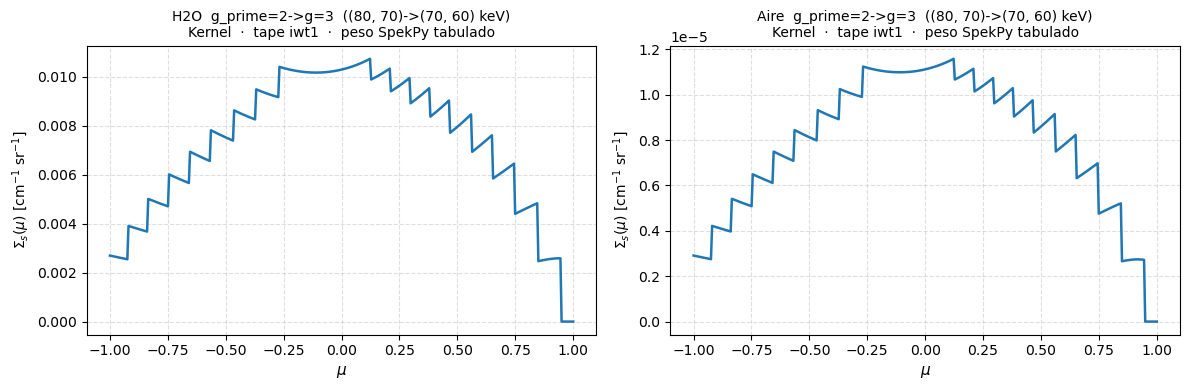

  Rango μ activo H2O: [-1.000, +0.945]
  Pico H2O: 1.0723e-02 cm^-1/sr


In [5]:
# CELDA 4 — Visualización del kernel continuo

ag = active_groups()
G_IN, G_OUT = ag[0], ag[1]
mu_plot = np.linspace(-1.0, 1.0, 400)

sig_H2O = np.array([mg_xs.sigma_scatter_at_mu(G_IN, G_OUT, float(m), RHO_H2O, COMP_H2O) for m in mu_plot])
sig_AIR = np.array([mg_xs.sigma_scatter_at_mu(G_IN, G_OUT, float(m), RHO_AIR, COMP_AIR) for m in mu_plot])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, sig, name in zip(axes, [sig_H2O, sig_AIR], ["H2O", "Aire"]):
    ax.plot(mu_plot, sig, lw=1.8)
    ax.set_xlabel(r"$\mu$", fontsize=11)
    ax.set_ylabel(r"$\Sigma_s(\mu)$ [cm$^{-1}$ sr$^{-1}$]", fontsize=10)
    ax.set_title(f"{name}  g_prime={G_IN}->g={G_OUT}  ({ENERGY_GROUPS[G_IN]}->{ENERGY_GROUPS[G_OUT]} keV)\n"
                 f"Kernel  ·  tape iwt1  ·  peso SpekPy tabulado", fontsize=10)
    ax.grid(True, ls="--", alpha=0.4)
plt.tight_layout(); plt.show()

mu_pos = mu_plot[sig_H2O > 0]
if len(mu_pos):
    print(f"  Rango μ activo H2O: [{mu_pos.min():+.3f}, {mu_pos.max():+.3f}]")
print(f"  Pico H2O: {sig_H2O.max():.4e} cm^-1/sr")

---
## Celda 5 — Helper de proyección con convención NJOY

**Convención NJOY GROUPR MF=6/MF=26:**

$$\sigma_l(g_{\text{prime}}\to g) \;=\; 2\pi\int_{-1}^{+1} P_l(\mu)\,\sigma_s^{g_{\text{prime}}\to g}(\mu)\,d\mu$$

El factor `2π` (no `(2l+1)·π`) es lo que NJOY escribe directamente en el bloque MF=26/MT=504.
Convención **idéntica** a la del notebook `iwt=3`; el peso `w(E)` cambia, la convención no.

In [6]:
# CELDA 5 — Proyección con convención NJOY (factor 2π)

def legendre_P(l, x):
    """P_l(x) recurrencia de Bonnet."""
    x = np.asarray(x, dtype=float)
    if l == 0: return np.ones_like(x)
    if l == 1: return x.copy()
    Pp, Pc = np.ones_like(x), x.copy()
    for n in range(1, l):
        Pn = ((2*n+1)*x*Pc - n*Pp)/(n+1)
        Pp, Pc = Pc, Pn
    return Pc


def project_moment(mg, g_prime, g, l, mu_nodes, w_nodes, rho, comp):
    """
    Σ_s^l(g'→g) [cm^-1]  con convención NJOY MF=26:
        Σ_s^l = 2π · ∫ P_l(μ) Σ_s(μ) dμ
    Integración Gauss-Legendre con (mu_nodes, w_nodes).
    """
    sig = np.array([mg.sigma_scatter_at_mu(g_prime, g, float(m), rho, comp)
                    for m in mu_nodes])
    Pl  = legendre_P(l, mu_nodes)
    integ = float(np.dot(w_nodes, Pl * sig))
    return 2.0 * math.pi * integ


def project_moment_per_element(mg, g_prime, g, l, mu_nodes, w_nodes,
                                elem, rho, w_e):
    """Idem para un elemento puro (para verificar aditividad de Bragg)."""
    sig = np.array([mg.sigma_scatter_per_element_at_mu(
                       g_prime, g, float(m), elem, rho, w_e)
                    for m in mu_nodes])
    Pl  = legendre_P(l, mu_nodes)
    integ = float(np.dot(w_nodes, Pl * sig))
    return 2.0 * math.pi * integ


print('OK  Convención: Σ_s^l = 2π · ∫ P_l(μ) Σ_s(μ) dμ   [NJOY MF=26]')


OK  Convención: Σ_s^l = 2π · ∫ P_l(μ) Σ_s(μ) dμ   [NJOY MF=26]


---
## Celda 6 — ◀ Rama A ▶ Gauss-Legendre **N = 26** (= S26 ≡ primeros vecinos)

**S26 = primeros vecinos.** Esta rama se compara con NJOY/GAMINR usando el mismo peso SpekPy de iwt=1.
La **FCS sólo se construye sobre esta rama** (S26 ≡ primeros vecinos).

In [7]:
# CELDA 6 — Rama A: N=26  (≡ S26, primeros vecinos)

N_A_QUAD = 26
MU_A, W_A = np.polynomial.legendre.leggauss(N_A_QUAD)

def moments_S26(mg, rho, comp, L_MAX=3):
    """Devuelve M[l, g_prime, g] [cm^-1] usando GL N=26."""
    M = np.zeros((L_MAX+1, N_GROUPS, N_GROUPS))
    for gp in range(N_GROUPS):
        for g in range(N_GROUPS):
            for l in range(L_MAX+1):
                M[l, gp, g] = project_moment(mg, gp, g, l, MU_A, W_A, rho, comp)
    return M

print(f"  Computando momentos S26 (N={N_A_QUAD}) con peso SpekPy (iwt=1) para H2O...")
M_H2O_S26 = moments_S26(mg_xs, RHO_H2O, COMP_H2O, L_MAX=3)
print(f"  Computando momentos S26 (N={N_A_QUAD}) con peso SpekPy (iwt=1) para Aire...")
M_AIR_S26 = moments_S26(mg_xs, RHO_AIR, COMP_AIR, L_MAX=3)
print(f"OK  Rama A — shape M = {M_H2O_S26.shape}  [S26 ≡ primeros vecinos]")

# Vista de los pares activos
print()
print("  Σ_s^l(g_prime->g) [cm^-1]  —  H2O  —  Rama A (S26, GL N=26):")
print("  {:>4} {:>4}  {:>14}  {:>14}  {:>14}  {:>14}".format("gp", "g", "l=0", "l=1", "l=2", "l=3"))
for gp in ag:
    for g in ag:
        if any(abs(M_H2O_S26[l, gp, g]) > 1e-20 for l in range(4)):
            print(f"  {gp:>4} {g:>4}  " +
                  "  ".join(f"{M_H2O_S26[l, gp, g]:>14.5e}" for l in range(4)))

  Computando momentos S26 (N=26) con peso SpekPy (iwt=1) para H2O...
  Computando momentos S26 (N=26) con peso SpekPy (iwt=1) para Aire...
OK  Rama A — shape M = (4, 10, 10)  [S26 ≡ primeros vecinos]

  Σ_s^l(g_prime->g) [cm^-1]  —  H2O  —  Rama A (S26, GL N=26):
    gp    g             l=0             l=1             l=2             l=3
     2    2     4.92942e-02     3.64099e-02     1.84912e-02     4.67159e-03
     2    3     9.16398e-02    -8.19547e-06    -1.48208e-02    -1.13994e-03
     2    4     3.07737e-02    -2.31548e-02     1.23082e-02    -3.57891e-03
     3    3     6.54475e-02     4.22753e-02     1.52376e-02     1.02806e-03
     3    4     1.06236e-01    -2.80161e-02    -2.04970e-03     1.50003e-04
     3    5     3.55334e-03    -3.17919e-03     2.52062e-03    -1.72910e-03
     4    4     9.31428e-02     4.21677e-02     7.39891e-03     2.32925e-03
     4    5     8.53578e-02    -3.36144e-02     7.97408e-03    -3.40952e-03
     5    5     1.16853e-01     3.03524e-02     1.00

---
## Celda 7 — ◀ Rama B ▶ Gauss-Legendre **N = 128** (= S128 ≡ segundos vecinos)

**S128 = segundos vecinos.** Esta rama se compara con NJOY/GAMINR usando el mismo peso SpekPy de iwt=1.

> ⚠ La FCS **NO** se extiende a segundos vecinos. La rama S128 sirve únicamente para verificar
> que el kernel angular del solver converge en cuadratura contra los momentos de NJOY.

In [8]:
# CELDA 7 — Rama B: N=128  (≡ S128, segundos vecinos)

N_B_QUAD = 128
MU_B, W_B = np.polynomial.legendre.leggauss(N_B_QUAD)

def moments_S128(mg, rho, comp, L_MAX=3):
    M = np.zeros((L_MAX+1, N_GROUPS, N_GROUPS))
    for gp in range(N_GROUPS):
        for g in range(N_GROUPS):
            for l in range(L_MAX+1):
                M[l, gp, g] = project_moment(mg, gp, g, l, MU_B, W_B, rho, comp)
    return M

print(f"  Computando momentos S128 (N={N_B_QUAD}) con peso SpekPy (iwt=1) para H2O...")
M_H2O_S128 = moments_S128(mg_xs, RHO_H2O, COMP_H2O, L_MAX=3)
print(f"  Computando momentos S128 (N={N_B_QUAD}) con peso SpekPy (iwt=1) para Aire...")
M_AIR_S128 = moments_S128(mg_xs, RHO_AIR, COMP_AIR, L_MAX=3)
print(f"OK  Rama B — shape M = {M_H2O_S128.shape}  [S128 ≡ segundos vecinos]")

# Efecto de la cuadratura aislado: S26 vs S128 (mismo kernel, mismo peso SpekPy)
print()
print("  Diferencia S26 vs S128 — H2O — pares activos (mismo peso SpekPy iwt=1):")
print("  {:>4} {:>4} {:>3}  {:>14}  {:>14}  {:>20}".format("gp", "g", "l", "S26", "S128", "(S26-S128)/S128 %"))
for gp in ag:
    for g in ag:
        for l in range(4):
            vA = M_H2O_S26[l, gp, g]
            vB = M_H2O_S128[l, gp, g]
            if abs(vA) < 1e-20 and abs(vB) < 1e-20: continue
            r = (vA-vB)/vB*100.0 if abs(vB) > 1e-20 else float("nan")
            print(f"  {gp:>4} {g:>4} {l:>3}  {vA:>14.5e}  {vB:>14.5e}  {r:>+18.3f}%")

  Computando momentos S128 (N=128) con peso SpekPy (iwt=1) para H2O...
  Computando momentos S128 (N=128) con peso SpekPy (iwt=1) para Aire...
OK  Rama B — shape M = (4, 10, 10)  [S128 ≡ segundos vecinos]

  Diferencia S26 vs S128 — H2O — pares activos (mismo peso SpekPy iwt=1):
    gp    g   l             S26            S128     (S26-S128)/S128 %
     2    2   0     4.92942e-02     4.99825e-02              -1.377%
     2    2   1     3.64099e-02     3.69019e-02              -1.333%
     2    2   2     1.84912e-02     1.87939e-02              -1.611%
     2    2   3     4.67159e-03     4.92606e-03              -5.166%
     2    3   0     9.16398e-02     9.17895e-02              -0.163%
     2    3   1    -8.19547e-06    -1.04272e-03             -99.214%
     2    3   2    -1.48208e-02    -1.51366e-02              -2.086%
     2    3   3    -1.13994e-03    -1.26116e-03              -9.612%
     2    4   0     3.07737e-02     2.98878e-02              +2.964%
     2    4   1    -2.31548e-

---
## Celda 8 — Parser GENDF MF=26 / MT=504  (lord=3, iwt=1)

**Layout NJOY GROUPR (manual §10) para MF=26:**

```
HEAD/CONT: [MAT, 26, MT/ ZA, AWR, NL, NZ, LRFLAG, NGN]
Por cada IG_prime (grupo incidente, 1-based, en orden ASCENDENTE de energía):
  LIST:  [MAT, 26, MT/ 0.0, 0.0, NG2, IG2LO, NW, IG_prime]
         seguido de NW = NL·NZ·NG2 valores reales en orden:
           data[k * NL * NZ + l * NZ + iz]   con
              k = 0..NG2-1   (k=0 ⇒ flujo de entrada del grupo IG_prime;
                              k≥1 ⇒ grupo saliente g = IG2LO + k - 1)
              l = 0..NL-1    (orden de Legendre)
              iz = 0..NZ-1   (índice de dilución — para iwt=1, NZ=1)
```

**Importante:** el primer "grupo" del bloque (k=0) NO es un grupo de salida; contiene
el flujo de entrada usado para el colapso. Los grupos de salida físicos son k=1..NG2-1.

NJOY graba en MF=26 `f_l(g_prime→g) = 2π·∫P_l·σ(μ)dμ` directamente (ya integrado azimutalmente).
Para `iwt=1` (peso tabulado SpekPy) NJOY divide por el flujo del grupo, dejando σ_l en
**barns/átomo**.

> El parser es el mismo del notebook `iwt=3`. La estructura MF=26 no cambia con `iwt`;
> cambian los **valores** de los momentos porque NJOY colapsó con otro peso.

In [9]:
# CELDA 8 — Parser GENDF MF=26 / MT=504
# Tapes actuales: *_iwt1 (peso espectral tabulado SpekPy).
# La estructura MF=26 es idéntica a la de iwt=2/iwt=3; cambian los VALORES de los
# momentos almacenados porque NJOY ha colapsado con otro peso.

import numpy as np, re
from pathlib import Path

# Rutas — coherentes con la Celda 1
TAPE_HO = "/home/rober/njoy_work/tapes/gendf_HO_0_100_10keV_lord3_iwt1"
TAPE_N  = "/home/rober/njoy_work/tapes/gendf_N_0_100_10keV_lord3_iwt1"

MAT_INFO = {100: ("H", 1, 1.00794), 800: ("O", 8, 15.9994), 700: ("N", 7, 14.0067)}


def _gd_float(s):
    s = s.strip()
    if not s: return 0.0
    try: return float(s)
    except ValueError:
        m = re.match(r"\s*([+-]?\d+\.?\d*)([+-]\d+)\s*$", s)
        if m: return float(m.group(1) + "e" + m.group(2))
        raise

def _gd_split(line):
    if len(line) < 66: line = line.ljust(66)
    fields = [line[i*11:(i+1)*11] for i in range(6)]
    return fields, line[66:70].strip(), line[70:72].strip(), line[72:75].strip()


def parse_gendf_mf26_mt504(filepath, NG_max=10, verbose=False):
    """Lee MF=26 / MT=504 (Compton incoherente, momentos de Legendre).

    Devuelve dict {elem: {M: array (L+1, NG, NG) [barns/atomo],
                          A: peso atómico, Z: Z, NL: L+1}}.
    """
    lines = Path(filepath).read_text(errors="ignore").splitlines()

    blocks = {}
    for ln in lines:
        if len(ln) < 75: continue
        _, mat, mf, mt = _gd_split(ln)
        try: mat, mf, mt = int(mat), int(mf), int(mt)
        except ValueError: continue
        if mat <= 0 or mf == 0 or mt == 0: continue
        blocks.setdefault((mat, mf, mt), []).append(ln)

    if verbose:
        mats_found = sorted({k[0] for k in blocks})
        print(f"    MATs encontrados en {Path(filepath).name}: {mats_found}")
        for mat in mats_found:
            mf_mt = sorted([(k[1], k[2]) for k in blocks if k[0] == mat])
            print(f"      MAT={mat}: (MF, MT) = {mf_mt}")

    result = {}

    for mat in sorted({k[0] for k in blocks}):
        if (mat, 26, 504) not in blocks:
            if verbose and mat in MAT_INFO:
                print(f"    WARN: MAT={mat} ({MAT_INFO[mat][0]}) no tiene bloque MF=26/MT=504")
            continue
        if mat not in MAT_INFO:
            if verbose:
                print(f"    WARN: MAT={mat} no está en MAT_INFO, se ignora")
            continue

        blk = blocks[(mat, 26, 504)]

        # HEAD/CONT GENDF MF=26: ZA, AWR, NL, NZ, LRFLAG, NGN
        flds0, *_ = _gd_split(blk[0])
        try:
            NL     = int(_gd_float(flds0[2]))
            NZ     = max(1, int(_gd_float(flds0[3])))
            LRFLAG = int(_gd_float(flds0[4]))
            NGN    = int(_gd_float(flds0[5]))
        except Exception:
            NL, NZ, LRFLAG, NGN = 4, 1, 0, NG_max

        if NL <= 0:
            raise ValueError(f"Cabecera MF=26/MT=504 mal leída: NL={NL} en MAT={mat}")

        M = np.zeros((NL, NG_max, NG_max))

        if verbose:
            print(f"  MAT={mat} ({MAT_INFO[mat][0]})  NL={NL} (lord={NL-1})  "
                  f"NZ={NZ}  LRFLAG={LRFLAG}  NGN={NGN}  lineas={len(blk)}")

        i = 1
        while i < len(blk):
            flds, *_ = _gd_split(blk[i])
            try:
                NG2   = int(_gd_float(flds[2]))
                IG2LO = int(_gd_float(flds[3]))
                NW    = int(_gd_float(flds[4]))
                IG    = int(_gd_float(flds[5]))
            except ValueError:
                i += 1; continue

            if NG2 <= 0 or NW <= 0 or IG <= 0:
                i += 1; continue

            n_lines = (NW + 5) // 6
            vals = []
            for j in range(1, n_lines + 1):
                if i + j >= len(blk): break
                row, *_ = _gd_split(blk[i + j])
                for f in row:
                    if f.strip() and len(vals) < NW:
                        try: vals.append(_gd_float(f))
                        except Exception: vals.append(0.0)
            vals = np.array(vals[:NW], dtype=float)

            expected = NG2 * NL * NZ
            try:
                if len(vals) >= expected:
                    data = vals[:expected].reshape((NG2, NL, NZ))
                elif NG2 * NL == len(vals):
                    data = vals.reshape((NG2, NL, 1))
                else:
                    if verbose:
                        print(f"    IG={IG} NG2={NG2} NL={NL} NZ={NZ} NW={NW} len(vals)={len(vals)} -- saltado")
                    i += 1 + n_lines
                    continue
            except Exception as e:
                if verbose:
                    print(f"    IG={IG} reshape failed: {e}")
                i += 1 + n_lines
                continue

            gp_njoy_0b = IG - 1

            # k=0 es el flujo, k=1..NG2-1 son grupos de salida
            for k in range(1, NG2):
                g_njoy_1b = IG2LO + (k - 1)
                g_njoy_0b = g_njoy_1b - 1
                if not (0 <= g_njoy_0b < NG_max): continue
                if not (0 <= gp_njoy_0b < NG_max): continue
                for l in range(NL):
                    M[l, gp_njoy_0b, g_njoy_0b] = data[k, l, 0]

            i += 1 + n_lines

        elem = MAT_INFO[mat][0]
        Z    = MAT_INFO[mat][1]
        A    = MAT_INFO[mat][2]
        result[elem] = {"M": M, "A": A, "Z": Z, "NL": NL}

    return result


def bragg_moments_macroscopic(elem_data, mixture, rho, L_MAX=3):
    """sigma_l por elemento [barns/atomo] -> Sigma_l [cm^-1] mezcla (Bragg)."""
    out = np.zeros((L_MAX+1, N_GROUPS, N_GROUPS))
    for el, w in mixture.items():
        if el not in elem_data: continue
        A_e = elem_data[el]["A"]
        M_e = elem_data[el]["M"][:L_MAX+1]
        out += rho * (N_A / A_e) * w * M_e * 1e-24
    return out


# ── Cargar tapes ─────────────────────────────────────────────────────────
print("Leyendo tapes NJOY/GAMINR  (MF=26, MT=504, lord=3, iwt=1):")
print(f"  TAPE_HO = {TAPE_HO}")
print(f"  TAPE_N  = {TAPE_N}")
print()

if not any(Path(p).exists() for p in [TAPE_HO, TAPE_N]):
    print("INFO  Tapes NJOY no encontrados.")
    print(f"      ¿Existe TAPE_HO?  {Path(TAPE_HO).exists()}")
    print(f"      ¿Existe TAPE_N?   {Path(TAPE_N).exists()}")
    M_H2O_NJOY = None
    M_AIR_NJOY = None
    njoy_data  = {}
else:
    njoy_data = {}
    for tp in [TAPE_HO, TAPE_N]:
        if Path(tp).exists():
            print(f"  Parseando {Path(tp).name} ...")
            try:
                d = parse_gendf_mf26_mt504(tp, NG_max=N_GROUPS, verbose=True)
                njoy_data.update(d)
            except Exception as e:
                import traceback
                print(f"  WARNING: {e}")
                traceback.print_exc()
        else:
            print(f"  (no existe: {tp})")

    if not njoy_data:
        print()
        print("INFO  Se leyeron 0 elementos. Comprueba el contenido de los tapes.")
        M_H2O_NJOY = None
        M_AIR_NJOY = None
    else:
        print()
        print(f"OK  Elementos leídos: {sorted(njoy_data.keys())}")
        print()
        print("  Diagnóstico: sigma_s^0(g_prime=g) [barns/atomo] -- diagonal, grupos activos")
        print(f"  {'el':>4}  {'g':>4}  {'sigma_0':>14}")
        for el in sorted(njoy_data.keys()):
            M_el = njoy_data[el]["M"]
            if M_el.ndim != 3 or M_el.shape[0] == 0:
                print(f"  WARN: {el} sin momentos válidos; shape={M_el.shape}")
                continue
            for g in active_groups():
                v = M_el[0, g, g]
                if abs(v) > 1e-20:
                    print(f"  {el:>4}  {g:>4}  {v:>14.5e}")

        M_H2O_NJOY = bragg_moments_macroscopic(njoy_data, MIX_H2O, RHO_H2O, L_MAX=3)
        M_AIR_NJOY = bragg_moments_macroscopic(njoy_data, MIX_AIR, RHO_AIR, L_MAX=3)
        print()
        print(f"OK  Bragg aplicado:  M_H2O_NJOY {M_H2O_NJOY.shape},  M_AIR_NJOY {M_AIR_NJOY.shape}")

Leyendo tapes NJOY/GAMINR  (MF=26, MT=504, lord=3, iwt=1):
  TAPE_HO = /home/rober/njoy_work/tapes/gendf_HO_0_100_10keV_lord3_iwt1
  TAPE_N  = /home/rober/njoy_work/tapes/gendf_N_0_100_10keV_lord3_iwt1

  Parseando gendf_HO_0_100_10keV_lord3_iwt1 ...
    MATs encontrados en gendf_HO_0_100_10keV_lord3_iwt1: [100, 800]
      MAT=100: (MF, MT) = [(1, 451), (23, 501), (23, 502), (23, 504), (23, 522), (26, 504)]
      MAT=800: (MF, MT) = [(1, 451), (23, 501), (23, 502), (23, 504), (23, 522), (26, 504)]
  MAT=100 (H)  NL=4 (lord=3)  NZ=1  LRFLAG=0  NGN=10  lineas=42
  MAT=800 (O)  NL=4 (lord=3)  NZ=1  LRFLAG=0  NGN=10  lineas=42
  Parseando gendf_N_0_100_10keV_lord3_iwt1 ...
    MATs encontrados en gendf_N_0_100_10keV_lord3_iwt1: [700]
      MAT=700: (MF, MT) = [(1, 451), (23, 501), (23, 502), (23, 504), (23, 522), (26, 504)]
  MAT=700 (N)  NL=4 (lord=3)  NZ=1  LRFLAG=0  NGN=10  lineas=42

OK  Elementos leídos: ['H', 'N', 'O']

  Diagnóstico: sigma_s^0(g_prime=g) [barns/atomo] -- diagonal, g

In [10]:
# CELDA 8b — Diagnóstico inmediato del parser (ejecutar tras celda 8)
# Verifica shape y NL de cada elemento antes de usar njoy_data.

if Path(TAPE_HO).exists() and Path(TAPE_N).exists():
    print("── TAPE_HO (iwt=1) ──")
    _d_HO = parse_gendf_mf26_mt504(TAPE_HO, NG_max=N_GROUPS, verbose=True)
    for el, info in _d_HO.items():
        print(f"  {el}  shape={info['M'].shape}  NL={info['NL']}")

    print()
    print("── TAPE_N (iwt=1) ──")
    _d_N = parse_gendf_mf26_mt504(TAPE_N, NG_max=N_GROUPS, verbose=True)
    for el, info in _d_N.items():
        print(f"  {el}  shape={info['M'].shape}  NL={info['NL']}")

    print()
    print("Esperado:  shape=(4, 10, 10)  NL=4  (lord=3, tapes iwt=1)")
else:
    print("(tapes iwt=1 no encontrados en esta máquina — diagnóstico omitido)")

── TAPE_HO (iwt=1) ──
    MATs encontrados en gendf_HO_0_100_10keV_lord3_iwt1: [100, 800]
      MAT=100: (MF, MT) = [(1, 451), (23, 501), (23, 502), (23, 504), (23, 522), (26, 504)]
      MAT=800: (MF, MT) = [(1, 451), (23, 501), (23, 502), (23, 504), (23, 522), (26, 504)]
  MAT=100 (H)  NL=4 (lord=3)  NZ=1  LRFLAG=0  NGN=10  lineas=42
  MAT=800 (O)  NL=4 (lord=3)  NZ=1  LRFLAG=0  NGN=10  lineas=42
  H  shape=(4, 10, 10)  NL=4
  O  shape=(4, 10, 10)  NL=4

── TAPE_N (iwt=1) ──
    MATs encontrados en gendf_N_0_100_10keV_lord3_iwt1: [700]
      MAT=700: (MF, MT) = [(1, 451), (23, 501), (23, 502), (23, 504), (23, 522), (26, 504)]
  MAT=700 (N)  NL=4 (lord=3)  NZ=1  LRFLAG=0  NGN=10  lineas=42
  N  shape=(4, 10, 10)  NL=4

Esperado:  shape=(4, 10, 10)  NL=4  (lord=3, tapes iwt=1)


---
## Celda 8c — Control del peso espectral del tape MF=26 (iwt=1)

In [11]:
# CELDA 8c — Control del peso espectral del tape MF=26
# Para los tapes iwt=1 el peso de colapso es el espectro SpekPy tabulado.
# Aquí no se intenta reconstruir el peso del tape; se comprueba sólo que MF=26
# se ha leído y los momentos no son nulos en los grupos activos.
# La consistencia cuantitativa del peso debe verificarse en el notebook de
# secciones eficaces (iwt1_sec) comparando colapsos sigma_g vs MF=23.

def inspect_mf26_flux(njoy_data, elem="O"):
    """Inspección cualitativa de los momentos almacenados en MF=26 (iwt=1)."""
    if elem not in njoy_data:
        print(f"{elem} no está en njoy_data")
        return

    M_el = njoy_data[elem]["M"]
    print(f"Elemento {elem}: M shape = {M_el.shape}")
    print("Nota: el flujo no se guarda en M porque el parser descarta k=0.")
    print("Para iwt=1 la coherencia del peso (SpekPy) se comprueba contra MF=23 en iwt1_sec.")
    print("Control principal aquí: verificar que MF=26 fue leído y tiene momentos no nulos.")
    print()

    for gp in GROUP_NJOY_IDX:
        vals = []
        for g in GROUP_NJOY_IDX:
            vals.append(abs(M_el[0, gp, g]))
        print(f"  gp NJOY={gp}: suma |l=0| activos = {sum(vals):.6e}")

if njoy_data:
    inspect_mf26_flux(njoy_data, elem="O")
else:
    print("(sin njoy_data — diagnóstico MF=26 omitido)")

Elemento O: M shape = (4, 10, 10)
Nota: el flujo no se guarda en M porque el parser descarta k=0.
Para iwt=1 la coherencia del peso (SpekPy) se comprueba contra MF=23 en iwt1_sec.
Control principal aquí: verificar que MF=26 fue leído y tiene momentos no nulos.

  gp NJOY=2: suma |l=0| activos = 4.117297e+00
  gp NJOY=3: suma |l=0| activos = 4.313743e+00
  gp NJOY=4: suma |l=0| activos = 4.299368e+00
  gp NJOY=5: suma |l=0| activos = 4.235989e+00
  gp NJOY=6: suma |l=0| activos = 4.166108e+00
  gp NJOY=7: suma |l=0| activos = 4.084509e+00


---
## Celda 9 — Comparación **S26 vs NJOY** (iwt=1, peso SpekPy)

Imprime **todos** los pares `(g_prime, g)` con `g_prime, g ∈ {2,...,7}` (los grupos activos),
sin filtrar nada. Los pares fuera de alcance cinemático aparecerán como `0 vs 0`.

**S26 = primeros vecinos.** El kernel del solver se ha colapsado con el mismo peso
SpekPy que NJOY/GAMINR usó para generar los tapes `*_iwt1`.

In [12]:
# CELDA 9 — S26 vs NJOY  (con remapeo BTE->NJOY correcto)
# Usa gp_bte/g_bte para indexar el solver y gp_n/g_n para indexar NJOY.
# Las matrices del solver NO se remapean: el remapeo ocurre en el índice de acceso.

def compare_direct_remap(M_solver, M_njoy, label, mat_name, L_MAX=3):
    """Comparación directa solver vs NJOY con remapeo de convención.

    M_solver: indexado en convención BTE  (GROUP_BTE_IDX).
    M_njoy  : indexado en convención NJOY (GROUP_NJOY_IDX).
    """
    if M_njoy is None:
        print(f"  (sin tape NJOY — comparación {label} {mat_name} omitida)")
        return None

    print(f"\n  ── {label}  ·  {mat_name}  ──")
    print("  {:>10} {:>10} {:>2}  {:>16}  {:>16}  {:>10}".format(
          "gp[keV]", "g[keV]", "l", "solver [cm^-1]", "NJOY [cm^-1]", "err %"))
    print("  " + "-"*72)

    err_per_l = {l: [] for l in range(L_MAX + 1)}

    for i_gp, lab_gp in enumerate(GROUP_LABELS):
        gp_bte = GROUP_BTE_IDX[i_gp]
        gp_n   = GROUP_NJOY_IDX[i_gp]
        for i_g, lab_g in enumerate(GROUP_LABELS):
            g_bte = GROUP_BTE_IDX[i_g]
            g_n   = GROUP_NJOY_IDX[i_g]
            for l in range(L_MAX + 1):
                vC = float(M_solver[l, gp_bte, g_bte])
                vN = float(M_njoy [l, gp_n,   g_n  ])
                if abs(vN) > 1e-25:
                    err = (vC - vN) / abs(vN) * 100.0
                    err_per_l[l].append(abs(err))
                    err_s = f"{err:+10.3f}"
                elif abs(vC) > 1e-25:
                    err_s = "   inf(NJOY=0)"
                else:
                    continue
                print(f"  {lab_gp:>10} {lab_g:>10} {l:>2}  {vC:>16.5e}  {vN:>16.5e}  {err_s}")
        print()

    print("  |err|_max por orden l:")
    for l in range(L_MAX + 1):
        if err_per_l[l]:
            print(f"    l={l}:  {max(err_per_l[l]):8.3f}%  (sobre {len(err_per_l[l])} pares)")
        else:
            print(f"    l={l}:  sin pares NJOY != 0")
    return err_per_l


print("OK  compare_direct_remap definida")
print("    Remapeo: solver usa GROUP_BTE_IDX; NJOY usa GROUP_NJOY_IDX")

print()
print("=" * 72)
print("  Celda 9 — S26 (N=26) vs NJOY MF=26   ·  tape iwt1  ·  peso SpekPy")
print("  S26 = primeros vecinos")
print("=" * 72)
err_S26_H2O = compare_direct_remap(M_H2O_S26, M_H2O_NJOY, "S26 (N=26)", "H2O")
print()
err_S26_AIR = compare_direct_remap(M_AIR_S26, M_AIR_NJOY, "S26 (N=26)", "Aire")

OK  compare_direct_remap definida
    Remapeo: solver usa GROUP_BTE_IDX; NJOY usa GROUP_NJOY_IDX

  Celda 9 — S26 (N=26) vs NJOY MF=26   ·  tape iwt1  ·  peso SpekPy
  S26 = primeros vecinos

  ── S26 (N=26)  ·  H2O  ──
     gp[keV]     g[keV]  l    solver [cm^-1]      NJOY [cm^-1]       err %
  ------------------------------------------------------------------------
       20-30      20-30  0       1.76563e-01       1.76460e-01      +0.058
       20-30      20-30  1      -8.59357e-04      -1.05358e-03     +18.435
       20-30      20-30  2       1.25950e-02       1.26823e-02      -0.689
       20-30      20-30  3      -2.88108e-03      -3.21892e-03     +10.496

       30-40      20-30  0       3.24760e-02       3.26506e-02      -0.535
       30-40      20-30  1      -1.33566e-02      -1.34371e-02      +0.600
       30-40      20-30  2       3.15004e-03       3.31502e-03      -4.977
       30-40      20-30  3      -2.00455e-03      -1.37408e-03     -45.883
       30-40      30-40  0   

---
## Celda 10 — Comparación **S128 vs NJOY** (iwt=1, peso SpekPy)

**S128 = segundos vecinos.** Convergencia de la cuadratura angular contra NJOY iwt=1.
Recordatorio: **la FCS sigue restringida a primeros vecinos (S26)**; esta rama sólo
sirve para verificar el kernel angular.

In [13]:
# CELDA 10 — S128 vs NJOY  (con remapeo BTE->NJOY correcto)
print("=" * 72)
print("  Celda 10 — S128 (N=128) vs NJOY MF=26   ·  tape iwt1  ·  peso SpekPy")
print("  S128 = segundos vecinos  (verificación angular, NO extiende la FCS)")
print("=" * 72)
err_S128_H2O = compare_direct_remap(M_H2O_S128, M_H2O_NJOY, "S128 (N=128)", "H2O")
print()
err_S128_AIR = compare_direct_remap(M_AIR_S128, M_AIR_NJOY, "S128 (N=128)", "Aire")

  Celda 10 — S128 (N=128) vs NJOY MF=26   ·  tape iwt1  ·  peso SpekPy
  S128 = segundos vecinos  (verificación angular, NO extiende la FCS)

  ── S128 (N=128)  ·  H2O  ──
     gp[keV]     g[keV]  l    solver [cm^-1]      NJOY [cm^-1]       err %
  ------------------------------------------------------------------------
       20-30      20-30  0       1.76339e-01       1.76460e-01      -0.069
       20-30      20-30  1      -7.82740e-04      -1.05358e-03     +25.707
       20-30      20-30  2       1.25581e-02       1.26823e-02      -0.979
       20-30      20-30  3      -2.83682e-03      -3.21892e-03     +11.870

       30-40      20-30  0       3.25909e-02       3.26506e-02      -0.183
       30-40      20-30  1      -1.38352e-02      -1.34371e-02      -2.962
       30-40      20-30  2       3.26823e-03       3.31502e-03      -1.411
       30-40      20-30  3      -1.80825e-03      -1.37408e-03     -31.598
       30-40      30-40  0       1.50497e-01       1.50553e-01      -0.037
  

---
## Celda 11 — Tabla lado a lado **S26 / S128 / NJOY** (iwt=1, peso SpekPy)

Comparación cruzada **S26 vs S128** y de ambos contra NJOY, todo con el mismo peso SpekPy.
La diferencia entre S26 y S128 mide la convergencia de la cuadratura angular, no un cambio
de física; el peso energético es idéntico en ambas ramas. Recordatorio:

- **S26 = primeros vecinos**
- **S128 = segundos vecinos**
- **FCS = sólo a primeros vecinos** (no se extiende a S128)

In [14]:
# CELDA 11 — Tabla lado a lado S26 / S128 / NJOY  (con remapeo BTE->NJOY)
# Mismo peso SpekPy en ambas ramas. Diferencia S26-S128 = convergencia angular.

if M_H2O_NJOY is None:
    print("  (sin tape NJOY — celda 11 omitida)")
else:
    rows = []
    for mat_name, M_A, M_B, M_N in [
        ("H2O",  M_H2O_S26, M_H2O_S128, M_H2O_NJOY),
        ("Aire", M_AIR_S26, M_AIR_S128, M_AIR_NJOY),
    ]:
        for i_gp, lab_gp in enumerate(GROUP_LABELS):
            gp_bte = GROUP_BTE_IDX[i_gp]
            gp_n   = GROUP_NJOY_IDX[i_gp]
            for i_g, lab_g in enumerate(GROUP_LABELS):
                g_bte = GROUP_BTE_IDX[i_g]
                g_n   = GROUP_NJOY_IDX[i_g]
                for l in range(4):
                    vN = float(M_N[l, gp_n,   g_n  ])
                    vA = float(M_A[l, gp_bte, g_bte])
                    vB = float(M_B[l, gp_bte, g_bte])
                    if abs(vN) < 1e-25 and abs(vA) < 1e-25 and abs(vB) < 1e-25:
                        continue
                    if abs(vN) > 1e-25:
                        rA = (vA - vN) / abs(vN) * 100.0
                        rB = (vB - vN) / abs(vN) * 100.0
                    else:
                        rA = rB = float("nan")
                    rows.append({
                        "Mat": mat_name,
                        "g_pair": f"{lab_gp}->{lab_g}",
                        "l": l,
                        "S26":  vA, "S128": vB, "NJOY": vN,
                        "err_S26_%":  rA, "err_S128_%": rB,
                    })

    df = pd.DataFrame(rows)
    pd.set_option("display.float_format",
                  lambda v: f"{v:.4e}" if isinstance(v, float) and abs(v) > 1e-3
                            else f"{v:.3f}")
    pd.set_option("display.width", 220)

    for mat in ["H2O", "Aire"]:
        sub = df[df.Mat == mat]
        if sub.empty: continue
        print()
        print("=" * 72); print(f"  {mat}  ·  iwt=1  ·  peso SpekPy"); print("=" * 72)
        print(sub.drop(columns="Mat").to_string(index=False))
        print()
        for l in range(4):
            subL = sub[sub.l == l]
            mask = subL["err_S26_%"].notna()
            if mask.sum() == 0: continue
            eA = subL.loc[mask, "err_S26_%"].abs().max()
            eB = subL.loc[mask, "err_S128_%"].abs().max()
            print(f"    l={l}:  |err|_max  S26 = {eA:7.2f}%   S128 = {eB:7.2f}%"
                  f"   (mejora S128: {eA-eB:+.2f} pp)")


  H2O  ·  iwt=1  ·  peso SpekPy
      g_pair  l         S26        S128        NJOY   err_S26_%  err_S128_%
20-30->20-30  0  1.7656e-01  1.7634e-01  1.7646e-01  5.8486e-02 -6.8862e-02
20-30->20-30  1      -0.001      -0.001 -1.0536e-03  1.8435e+01  2.5707e+01
20-30->20-30  2  1.2595e-02  1.2558e-02  1.2682e-02 -6.8852e-01 -9.7932e-01
20-30->20-30  3 -2.8811e-03 -2.8368e-03 -3.2189e-03  1.0496e+01  1.1870e+01
30-40->20-30  0  3.2476e-02  3.2591e-02  3.2651e-02 -5.3487e-01 -1.8305e-01
30-40->20-30  1 -1.3357e-02 -1.3835e-02 -1.3437e-02  5.9956e-01 -2.9624e+00
30-40->20-30  2  3.1500e-03  3.2682e-03  3.3150e-03 -4.9767e+00 -1.4114e+00
30-40->20-30  3 -2.0046e-03 -1.8083e-03 -1.3741e-03 -4.5883e+01 -3.1598e+01
30-40->30-40  0  1.5062e-01  1.5050e-01  1.5055e-01  4.1447e-02 -3.7250e-02
30-40->30-40  1  1.4321e-02  1.4796e-02  1.4396e-02 -5.1861e-01  2.7808e+00
30-40->30-40  2  1.1126e-02  1.1005e-02  1.0965e-02  1.4684e+00  3.5686e-01
30-40->30-40  3      -0.000      -0.001 -1.1083e-03  5.

---
## Celda 12 — Diagnóstico por elemento puro (verificación Bragg, iwt=1)

Si la mezcla H₂O no cuadra pero los elementos puros sí, el problema es Bragg.  
Si los elementos puros tampoco cuadran, el problema es el kernel angular, el parser
o, en el caso `iwt=1`, una inconsistencia en la **lectura/interpolación del peso SpekPy**.

Comparación **elemento puro** (sin Bragg) usando N=128:
$\sigma_l(g_{\text{prime}}\to g)$ por elemento, solver vs NJOY, en **barns/átomo**.

In [15]:
# CELDA 12 — Diagnóstico por elemento puro

if not njoy_data:
    print("  (sin tape NJOY — celda 12 omitida)")
else:
    def moment_per_element_solver(mg, gp, g, l, elem, mu_nodes, w_nodes):
        """sigma_l(g_prime->g) [barns/atomo] del solver para elemento puro.

        Construye Sigma por elemento con w_e=1 y rho=1, luego divide por (N_A/A_e)*1e-24
        para devolver barns/atomo.
        """
        A_e = _A_ELEM[elem]
        sig = np.array([mg.sigma_scatter_per_element_at_mu(gp, g, float(m),
                                                            elem, 1.0, 1.0)
                        for m in mu_nodes])
        Pl  = legendre_P(l, mu_nodes)
        integ = float(np.dot(w_nodes, Pl * sig))
        Sigma_macro = 2.0*math.pi * integ
        sigma_atom_b = Sigma_macro / ((N_A/A_e) * 1.0 * 1.0) * 1e24
        return sigma_atom_b

    print("═"*70)
    print("  Celda 12 — Solver vs NJOY por elemento puro  [barns/átomo]")
    print("  Solver: GL N=128;   NJOY: MF=26/MT=504, tape iwt1, peso SpekPy")
    print("═"*70)
    for elem in sorted(njoy_data.keys()):
        print(f"\n  ── {elem}  (A={njoy_data[elem]['A']:.5g}, Z={njoy_data[elem]['Z']}) ──")
        print("  {:>14} {:>2}  {:>14}  {:>14}  {:>9}".format("gp->g [keV]", "l", "solver", "NJOY", "err %"))
        for i_gp, lab_gp in enumerate(GROUP_LABELS):
            gp_bte = GROUP_BTE_IDX[i_gp]
            gp_n   = GROUP_NJOY_IDX[i_gp]
            for i_g, lab_g in enumerate(GROUP_LABELS):
                g_bte = GROUP_BTE_IDX[i_g]
                g_n   = GROUP_NJOY_IDX[i_g]
                for l in range(4):
                    vC = moment_per_element_solver(mg_xs, gp_bte, g_bte, l, elem, MU_B, W_B)
                    vN = float(njoy_data[elem]["M"][l, gp_n, g_n])
                    if abs(vN) < 1e-25 and abs(vC) < 1e-25: continue
                    if abs(vN) > 1e-25:
                        err = (vC - vN) / abs(vN) * 100.0
                        err_s = f"{err:>+8.2f}"
                    else:
                        err_s = "  inf (NJOY=0)"
                    print(f"  {lab_gp:>6}->{lab_g:<6} {l:>2}  {vC:>14.5e}  {vN:>14.5e}  {err_s}")
            print()

══════════════════════════════════════════════════════════════════════
  Celda 12 — Solver vs NJOY por elemento puro  [barns/átomo]
  Solver: GL N=128;   NJOY: MF=26/MT=504, tape iwt1, peso SpekPy
══════════════════════════════════════════════════════════════════════

  ── H  (A=1.0079, Z=1) ──
     gp->g [keV]  l          solver            NJOY      err %
   20-30->20-30   0     5.81692e-01     5.80761e-01     +0.16
   20-30->20-30   1     2.44255e-02     2.34773e-02     +4.04
   20-30->20-30   2     5.24197e-02     5.26486e-02     -0.43
   20-30->20-30   3    -1.50253e-03    -2.68106e-03    +43.96

   30-40->20-30   0     1.00439e-01     1.00631e-01     -0.19
   30-40->20-30   1    -4.15274e-02    -4.00409e-02     -3.71
   30-40->20-30   2     9.58259e-03     9.88531e-03     -3.06
   30-40->20-30   3    -5.71576e-03    -4.26539e-03    -34.00
   30-40->30-40   0     4.83512e-01     4.82774e-01     +0.15
   30-40->30-40   1     6.67762e-02     6.52664e-02     +2.31
   30-40->30-40   2 

---
## Celda 13 — Resumen final (iwt=1)

In [16]:
# CELDA 13 — Resumen final
print("═"*72)
print("  RESUMEN FINAL — Legendre / NJOY MF=26 / MT=504 / iwt=1 / peso SpekPy")
print("═"*72)
print()
print("  Convención:  Σ_s^l(gp->g) = 2π · ∫ P_l(μ) Σ_s(μ) dμ   [NJOY MF=26]")
print(f"  IWT = {IWT}  (peso espectral tabulado SpekPy, leído de archivo)")
print(f"  Archivo de peso: {WEIGHT_SPEKPY}")
print(f"  Rama A:      Gauss-Legendre N={N_A_QUAD}   (≡ S26 en μ, primeros vecinos)")
print(f"  Rama B:      Gauss-Legendre N={N_B_QUAD}  (≡ S128 en μ, segundos vecinos)")
print(f"  FCS:         restringida a primeros vecinos (S26) — NO se extiende a S128")
print()

if M_H2O_NJOY is not None:
    # Tabla de errores por rama y orden l
    print("  ── Errores contra NJOY (peso SpekPy iwt=1) ──")
    print(f"  {'Mat':>6}  {'Rama':>5}  {'l':>3}  "
          f"{'|err|_max [%]':>14}  {'|err|_mean [%]':>15}  {'n_pares':>8}")
    summary_rows = []
    for mat_name, e_A, e_B in [
        ("H2O",  err_S26_H2O,  err_S128_H2O),
        ("Aire", err_S26_AIR,  err_S128_AIR),
    ]:
        for rama_name, e_dict in [("S26", e_A), ("S128", e_B)]:
            if e_dict is None: continue
            for l in range(4):
                vals = e_dict.get(l, [])
                if not vals:
                    print(f"  {mat_name:>6}  {rama_name:>5}  {l:>3}  "
                          f"{0.0:>14.3f}  {0.0:>15.3f}  {0:>8}")
                    continue
                m_max  = max(vals)
                m_mean = sum(vals) / len(vals)
                n      = len(vals)
                summary_rows.append((mat_name, rama_name, l, m_max, m_mean, n))
                print(f"  {mat_name:>6}  {rama_name:>5}  {l:>3}  "
                      f"{m_max:>14.3f}  {m_mean:>15.3f}  {n:>8}")

    # Peor orden l por rama
    print()
    print("  ── Peor orden l (por rama, considerando ambos materiales) ──")
    worst_per_rama = {"S26": {}, "S128": {}}
    for mat_name, rama_name, l, m_max, m_mean, n in summary_rows:
        prev = worst_per_rama[rama_name].get(l, (-1.0, ""))
        if m_max > prev[0]:
            worst_per_rama[rama_name][l] = (m_max, mat_name)
    for rama_name in ("S26", "S128"):
        d = worst_per_rama[rama_name]
        if not d: continue
        l_worst = max(d.keys(), key=lambda l: d[l][0])
        m_max, mat_worst = d[l_worst]
        print(f"    {rama_name:>5}: peor l = {l_worst}   |err|_max = {m_max:.3f} %   (en {mat_worst})")

    # Peor par gp->g por rama
    print()
    print("  ── Peor par gp->g (por rama) ──")
    try:
        rows_pairs = []
        for mat_name, M_A_local, M_B_local, M_N_local in [
            ("H2O",  M_H2O_S26, M_H2O_S128, M_H2O_NJOY),
            ("Aire", M_AIR_S26, M_AIR_S128, M_AIR_NJOY),
        ]:
            for i_gp, lab_gp in enumerate(GROUP_LABELS):
                gp_bte = GROUP_BTE_IDX[i_gp]
                gp_n   = GROUP_NJOY_IDX[i_gp]
                for i_g, lab_g in enumerate(GROUP_LABELS):
                    g_bte = GROUP_BTE_IDX[i_g]
                    g_n   = GROUP_NJOY_IDX[i_g]
                    for l in range(4):
                        vN = float(M_N_local[l, gp_n, g_n])
                        if abs(vN) < 1e-25: continue
                        vA = float(M_A_local[l, gp_bte, g_bte])
                        vB = float(M_B_local[l, gp_bte, g_bte])
                        rA = abs(vA - vN) / abs(vN) * 100.0
                        rB = abs(vB - vN) / abs(vN) * 100.0
                        rows_pairs.append((mat_name, l, f"{lab_gp}->{lab_g}", rA, rB))
        if rows_pairs:
            worst_S26  = max(rows_pairs, key=lambda r: r[3])
            worst_S128 = max(rows_pairs, key=lambda r: r[4])
            print(f"    S26 : peor par = {worst_S26[2]:>10}  l={worst_S26[1]}  "
                  f"mat={worst_S26[0]}  |err|={worst_S26[3]:.3f} %")
            print(f"    S128: peor par = {worst_S128[2]:>10}  l={worst_S128[1]}  "
                  f"mat={worst_S128[0]}  |err|={worst_S128[4]:.3f} %")
    except Exception as e:
        print(f"    (no se pudo computar peor par gp->g: {e})")

    print()
    print("  ── Memo técnico ──")
    print("    código     : colapso multigrupo con w(E) = SpekPy(E) (tabulado).")
    print(f"    referencia : tapes NJOY/GAMINR iwt=1")
    print(f"                 {TAPE_HO}")
    print(f"                 {TAPE_N}")
    print(f"    peso       : {WEIGHT_SPEKPY}")
    print("    S26        = primeros vecinos")
    print("    S128       = segundos vecinos")
    print("    FCS        : sólo a primeros vecinos (no se extiende a S128)")
else:
    print("  Sin tape NJOY accesible — comparación NO disponible.")

════════════════════════════════════════════════════════════════════════
  RESUMEN FINAL — Legendre / NJOY MF=26 / MT=504 / iwt=1 / peso SpekPy
════════════════════════════════════════════════════════════════════════

  Convención:  Σ_s^l(gp->g) = 2π · ∫ P_l(μ) Σ_s(μ) dμ   [NJOY MF=26]
  IWT = 1  (peso espectral tabulado SpekPy, leído de archivo)
  Archivo de peso: /home/rober/njoy_work/tapes/spekpy_weight_iwt1_96.txt
  Rama A:      Gauss-Legendre N=26   (≡ S26 en μ, primeros vecinos)
  Rama B:      Gauss-Legendre N=128  (≡ S128 en μ, segundos vecinos)
  FCS:         restringida a primeros vecinos (S26) — NO se extiende a S128

  ── Errores contra NJOY (peso SpekPy iwt=1) ──
     Mat   Rama    l   |err|_max [%]   |err|_mean [%]   n_pares
     H2O    S26    0          12.394            1.740        13
     H2O    S26    1          98.541           11.048        13
     H2O    S26    2          15.208            4.732        13
     H2O    S26    3          64.274           20.755       

In [17]:
# ============================================================
# CELDA 11b — Diagnóstico robusto de errores de Legendre  (iwt=1)
# ============================================================
# Problema:
#   En l=1,2,3 los momentos pueden ser pequeños o cambiar de signo.
#   Entonces el error relativo clásico:
#
#       err_l = (solver_l - NJOY_l) / NJOY_l
#
#   puede ser enorme aunque el error absoluto sea físicamente pequeño.
#
# Solución:
#   Además del error relativo por momento, calculamos:
#
#       err_norm_M0 = |solver_l - NJOY_l| / max(|NJOY_l=0| de la fila gp|) * 100
#
#   Esto mide el error de cada momento respecto a la escala física dominante
#   del grupo incidente, normalmente el momento l=0.
#
# Mismo esquema que en iwt=3. Sólo cambia el peso usado en el colapso del solver
# y, naturalmente, los valores de los momentos de NJOY (tape iwt1).
#
# Diagnóstico técnico — si aparecen discrepancias, NO cambiar la física;
# revisar en este orden:
#   1) lectura del peso SpekPy (formato, unidades, cabeceras)
#   2) interpolación del peso (rango cubierto vs [E_MIN_KEV, E_MAX_KEV])
#   3) normalización de los momentos (factor 2π, integración en μ)
#   4) orden de grupos (GROUP_BTE_IDX vs GROUP_NJOY_IDX)
#   5) parser GENDF (k=0 = flujo, k>=1 = grupos salida)
#   6) definición NJOY/GAMINR iwt=1 (peso = SpekPy tabulado)
#   7) comparación S26 (primeros vecinos) vs S128 (segundos vecinos)
# ============================================================

import numpy as np
import pandas as pd

def diagnostic_legendre_errors(M_solver, M_njoy, label, mat_name, L_MAX=3, eps=1e-30):
    """Diagnóstico robusto de errores de momentos de Legendre."""

    rows = []

    for i_gp, lab_gp in enumerate(GROUP_LABELS):
        gp_bte = GROUP_BTE_IDX[i_gp]
        gp_n = GROUP_NJOY_IDX[i_gp]

        m0_row_vals = []
        for i_g in range(len(GROUP_LABELS)):
            g_n = GROUP_NJOY_IDX[i_g]
            m0_row_vals.append(abs(float(M_njoy[0, gp_n, g_n])))

        scale_m0_row = max(m0_row_vals) if m0_row_vals else 0.0

        for i_g, lab_g in enumerate(GROUP_LABELS):
            g_bte = GROUP_BTE_IDX[i_g]
            g_n = GROUP_NJOY_IDX[i_g]

            m0_pair = abs(float(M_njoy[0, gp_n, g_n]))

            for l in range(L_MAX + 1):
                vS = float(M_solver[l, gp_bte, g_bte])
                vN = float(M_njoy[l, gp_n, g_n])
                diff = vS - vN

                if abs(vS) < eps and abs(vN) < eps:
                    continue

                if abs(vN) > eps:
                    err_rel_l = 100.0 * diff / abs(vN)
                else:
                    err_rel_l = np.nan

                if m0_pair > eps:
                    err_abs_norm_pair_m0 = 100.0 * abs(diff) / m0_pair
                else:
                    err_abs_norm_pair_m0 = np.nan

                if scale_m0_row > eps:
                    err_abs_norm_row_m0 = 100.0 * abs(diff) / scale_m0_row
                else:
                    err_abs_norm_row_m0 = np.nan

                rows.append({
                    "Mat": mat_name,
                    "Rama": label,
                    "g_pair": f"{lab_gp}->{lab_g}",
                    "l": l,
                    "solver": vS,
                    "NJOY": vN,
                    "diff": diff,
                    "err_rel_l_%": err_rel_l,
                    "err_abs_norm_pairM0_%": err_abs_norm_pair_m0,
                    "err_abs_norm_rowM0_%": err_abs_norm_row_m0,
                })

    return pd.DataFrame(rows)


# ------------------------------------------------------------
# Ejecutar diagnóstico para H2O y Aire
# ------------------------------------------------------------

dfs_diag = []

if M_H2O_NJOY is not None:
    dfs_diag.append(diagnostic_legendre_errors(M_H2O_S26,  M_H2O_NJOY, "S26",  "H2O"))
    dfs_diag.append(diagnostic_legendre_errors(M_H2O_S128, M_H2O_NJOY, "S128", "H2O"))
    dfs_diag.append(diagnostic_legendre_errors(M_AIR_S26,  M_AIR_NJOY, "S26",  "Aire"))
    dfs_diag.append(diagnostic_legendre_errors(M_AIR_S128, M_AIR_NJOY, "S128", "Aire"))

    df_diag = pd.concat(dfs_diag, ignore_index=True)

    pd.set_option("display.width", 240)
    pd.set_option("display.max_rows", 300)
    pd.set_option("display.float_format", lambda x: f"{x:.4e}")

    print("="*120)
    print("CELDA 11b — Diagnóstico robusto de errores de Legendre  (iwt=1, peso SpekPy)")
    print("="*120)
    print()
    print("Columnas importantes:")
    print("  err_rel_l_%              = error relativo clásico respecto a NJOY_l.")
    print("  err_abs_norm_pairM0_%    = |diff| normalizado al |NJOY_l0| del mismo par gp->g.")
    print("  err_abs_norm_rowM0_%     = |diff| normalizado al mayor |NJOY_l0| de la fila gp.")
    print()
    print("Interpretación:")
    print("  Si err_rel_l_% es grande pero err_abs_norm_rowM0_% es pequeño,")
    print("  el porcentaje está inflado porque el momento l es pequeño.")
    print("="*120)

    # Resumen por material, rama y orden l
    summary_rows = []

    for mat in ["H2O", "Aire"]:
        for rama in ["S26", "S128"]:
            for l in range(4):
                sub = df_diag[
                    (df_diag["Mat"] == mat) &
                    (df_diag["Rama"] == rama) &
                    (df_diag["l"] == l)
                ]

                if sub.empty:
                    continue

                summary_rows.append({
                    "Mat": mat,
                    "Rama": rama,
                    "l": l,
                    "max |err_rel_l| [%]": np.nanmax(np.abs(sub["err_rel_l_%"])),
                    "max err norm par M0 [%]": np.nanmax(sub["err_abs_norm_pairM0_%"]),
                    "max err norm fila M0 [%]": np.nanmax(sub["err_abs_norm_rowM0_%"]),
                    "mean err norm fila M0 [%]": np.nanmean(sub["err_abs_norm_rowM0_%"]),
                    "n_pares": len(sub),
                })

    df_summary_diag = pd.DataFrame(summary_rows)

    print("\nRESUMEN ROBUSTO POR ORDEN l  (iwt=1, peso SpekPy)")
    print("-"*120)
    print(df_summary_diag.to_string(index=False))

    print("\nCASOS CON MAYOR ERROR RELATIVO CLÁSICO")
    print("-"*120)

    cols_show = [
        "Mat", "Rama", "g_pair", "l",
        "solver", "NJOY", "diff",
        "err_rel_l_%",
        "err_abs_norm_pairM0_%",
        "err_abs_norm_rowM0_%",
    ]

    worst_rel = (
        df_diag
        .assign(abs_err_rel=lambda d: np.abs(d["err_rel_l_%"]))
        .sort_values("abs_err_rel", ascending=False)
        .head(30)
    )

    print(worst_rel[cols_show].to_string(index=False))

    print("\nCASOS FÍSICAMENTE MÁS RELEVANTES: MAYOR ERROR NORMALIZADO A M0 DE LA FILA")
    print("-"*120)

    worst_norm = (
        df_diag
        .sort_values("err_abs_norm_rowM0_%", ascending=False)
        .head(30)
    )

    print(worst_norm[cols_show].to_string(index=False))

else:
    print("Sin M_H2O_NJOY/M_AIR_NJOY accesible — diagnóstico omitido.")

CELDA 11b — Diagnóstico robusto de errores de Legendre  (iwt=1, peso SpekPy)

Columnas importantes:
  err_rel_l_%              = error relativo clásico respecto a NJOY_l.
  err_abs_norm_pairM0_%    = |diff| normalizado al |NJOY_l0| del mismo par gp->g.
  err_abs_norm_rowM0_%     = |diff| normalizado al mayor |NJOY_l0| de la fila gp.

Interpretación:
  Si err_rel_l_% es grande pero err_abs_norm_rowM0_% es pequeño,
  el porcentaje está inflado porque el momento l es pequeño.

RESUMEN ROBUSTO POR ORDEN l  (iwt=1, peso SpekPy)
------------------------------------------------------------------------------------------------------------------------
 Mat Rama  l  max |err_rel_l| [%]  max err norm par M0 [%]  max err norm fila M0 [%]  mean err norm fila M0 [%]  n_pares
 H2O  S26  0           1.2394e+01               1.2394e+01                1.7047e+00                 5.4669e-01       13
 H2O  S26  1           9.8541e+01               1.1430e+01                1.3573e+00                 3.9335e